<a href="https://colab.research.google.com/github/japmanyakaur/early-disease-detection-in-crops/blob/main/crop_disease_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Disease Detection — Training (v6, STABLE)

**This replaces every earlier version.** If you have older `crop_disease_tomato_grape*.ipynb` files anywhere (Colab tabs, Drive, Downloads), close/delete them now before continuing.

**What changed from earlier versions, and why:**
- The architecture bake-off is gone — we already ran it and know the answer (MobileNetV3), so it's hardcoded below. Fewer moving parts, fewer chances to break.
- The field-finetune stage no longer tries to pick a "best" epoch using a tiny, noisy slice of field data — that's what caused results to swing unpredictably (sometimes better, sometimes worse than doing nothing) across our last several runs. It now trains on *all* available real field photos, backbone frozen (classifier layer only, to avoid destroying what the model already learned), for a fixed number of epochs. Simpler, more predictable.
- No more "best checkpoint" comparison logic anywhere. Every epoch saves its progress (for disconnect-safety); the final epoch is the final model. Deterministic - re-running gives the same result.

**On accuracy:** lab-photo accuracy will be ~98%, reliably, every run - that's a real, legitimate, strong number. Real-field-photo accuracy is a genuinely harder, data-limited problem (see the Section 4 image comparison to understand why) - this version gives it the most stable shot we can, but don't expect a guaranteed specific number until you see it.

Runtime > Change runtime type > T4 GPU, before running anything below.

In [1]:
import torch, random, numpy as np
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using:", torch.cuda.get_device_name(0))
else:
    print("Go to Runtime > Change runtime type > select T4 GPU, then re-run this cell.")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


GPU available: True
Using: Tesla T4


## 1. Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os

PROJECT_DIR = '/content/drive/MyDrive/crop-disease-model'
CKPT_DIR    = f'{PROJECT_DIR}/checkpoints'
DATA_CACHE  = f'{PROJECT_DIR}/data_cache'
for d in [PROJECT_DIR, CKPT_DIR, DATA_CACHE]:
    os.makedirs(d, exist_ok=True)
print("Everything persists under:", PROJECT_DIR)


Mounted at /content/drive
Everything persists under: /content/drive/MyDrive/crop-disease-model


## 2. Install dependencies

In [3]:
!pip install -q kagglehub timm scikit-learn grad-cam opencv-python-headless


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 3. Get the dataset (cached to Drive after first run)

In [4]:
import shutil, glob, zipfile

DATA_DIR = "/content/data"
CACHE_ZIP = f"{DATA_CACHE}/tomato_grape_filtered_v3.zip"

def cache_looks_valid():
    return (os.path.isdir(f"{DATA_DIR}/train/tomato") and os.path.isdir(f"{DATA_DIR}/train/grape")
            and os.path.isdir(f"{DATA_DIR}/field_finetune/tomato") and os.path.isdir(f"{DATA_DIR}/field_finetune/grape"))

used_cache = False
if os.path.exists(CACHE_ZIP):
    print("Found cached filtered dataset on Drive - restoring (fast).")
    with zipfile.ZipFile(CACHE_ZIP) as zf:
        zf.extractall("/content")
    if cache_looks_valid():
        used_cache = True
        print("Restored to", DATA_DIR)
    else:
        print("Cached data is missing or old-format - rebuilding.")
        shutil.rmtree(DATA_DIR, ignore_errors=True)

if not used_cache:
    print("Downloading + filtering from scratch...")
    import kagglehub
    pv_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    train_dirs = glob.glob(pv_path + "/**/train", recursive=True)
    valid_dirs = glob.glob(pv_path + "/**/valid", recursive=True)
    if not train_dirs or not valid_dirs:
        raise RuntimeError("Could not find train/valid folders - inspect glob.glob(pv_path + '/**', recursive=True)")
    PV_TRAIN, PV_VALID = train_dirs[0], valid_dirs[0]

    def filter_crop_folders(src_dir, dst_dir, keywords):
        os.makedirs(dst_dir, exist_ok=True)
        kept = []
        for folder in sorted(glob.glob(f"{src_dir}/*")):
            name = os.path.basename(folder)
            if any(k in name for k in keywords):
                shutil.copytree(folder, f"{dst_dir}/{name}", dirs_exist_ok=True)
                kept.append(name)
        print(f"{dst_dir}: kept {len(kept)} classes")
        return kept

    for split, src in [("train", PV_TRAIN), ("valid", PV_VALID)]:
        filter_crop_folders(src, f"{DATA_DIR}/{split}/tomato", ("Tomato", "tomato"))
        filter_crop_folders(src, f"{DATA_DIR}/{split}/grape", ("Grape", "grape"))

    get_ipython().system("rm -rf /content/plantdoc")
    get_ipython().system("git clone --quiet --filter=blob:none --sparse https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc")
    get_ipython().run_line_magic("cd", "/content/plantdoc")
    get_ipython().system('git sparse-checkout set "train/*Tomato*" "train/*tomato*" "train/*Grape*" "train/*grape*" "test/*Tomato*" "test/*tomato*" "test/*Grape*" "test/*grape*"')
    get_ipython().run_line_magic("cd", "/content")

    PLANTDOC_TO_PLANTVILLAGE = {
        "Tomato leaf bacterial spot":         "Tomato___Bacterial_spot",
        "Tomato Early blight leaf":           "Tomato___Early_blight",
        "Tomato leaf late blight":            "Tomato___Late_blight",
        "Tomato mold leaf":                   "Tomato___Leaf_Mold",
        "Tomato Septoria leaf spot":          "Tomato___Septoria_leaf_spot",
        "Tomato two spotted spider mites leaf": "Tomato___Spider_mites Two-spotted_spider_mite",
        "Tomato leaf yellow virus":           "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
        "Tomato leaf mosaic virus":           "Tomato___Tomato_mosaic_virus",
        "Tomato leaf":                        "Tomato___healthy",
        "grape leaf black rot":               "Grape___Black_rot",
        "grape leaf":                         "Grape___healthy",
    }

    PLANTDOC_SPLIT_TO_OURS = {"train": "field_finetune", "test": "field_eval"}
    for pd_split, our_split in PLANTDOC_SPLIT_TO_OURS.items():
        for pd_name, pv_name in PLANTDOC_TO_PLANTVILLAGE.items():
            src = f"/content/plantdoc/{pd_split}/{pd_name}"
            if os.path.isdir(src):
                crop_dir = "tomato" if pv_name.startswith("Tomato") else "grape"
                dst = f"{DATA_DIR}/{our_split}/{crop_dir}/{pv_name}"
                os.makedirs(dst, exist_ok=True)
                for f in os.listdir(src):
                    shutil.copy(os.path.join(src, f), dst)

    print("Caching filtered dataset to Drive...")
    shutil.make_archive(CACHE_ZIP.replace(".zip", ""), "zip", "/content", "data")
    print("Cached at", CACHE_ZIP)

FIELD_FINETUNE_DIR = f"{DATA_DIR}/field_finetune"
FIELD_EVAL_DIR = f"{DATA_DIR}/field_eval"
print("\nReady.")


Found cached filtered dataset on Drive - restoring (fast).
Restored to /content/data

Ready.


## 4. Sanity check — see the actual images, lab vs real field

=== Training set class counts ===
  train/tomato/Tomato___Bacterial_spot: 1702
  train/tomato/Tomato___Early_blight: 1920
  train/tomato/Tomato___Late_blight: 1851
  train/tomato/Tomato___Leaf_Mold: 1882
  train/tomato/Tomato___Septoria_leaf_spot: 1745
  train/tomato/Tomato___Spider_mites Two-spotted_spider_mite: 1741
  train/tomato/Tomato___Target_Spot: 1827
  train/tomato/Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961
  train/tomato/Tomato___Tomato_mosaic_virus: 1790
  train/tomato/Tomato___healthy: 1926
  train/grape/Grape___Black_rot: 1888
  train/grape/Grape___Esca_(Black_Measles): 1920
  train/grape/Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722
  train/grape/Grape___healthy: 1692
  valid/tomato/Tomato___Bacterial_spot: 425
  valid/tomato/Tomato___Early_blight: 480
  valid/tomato/Tomato___Late_blight: 463
  valid/tomato/Tomato___Leaf_Mold: 470
  valid/tomato/Tomato___Septoria_leaf_spot: 436
  valid/tomato/Tomato___Spider_mites Two-spotted_spider_mite: 435
  valid/tomato/Tomato___

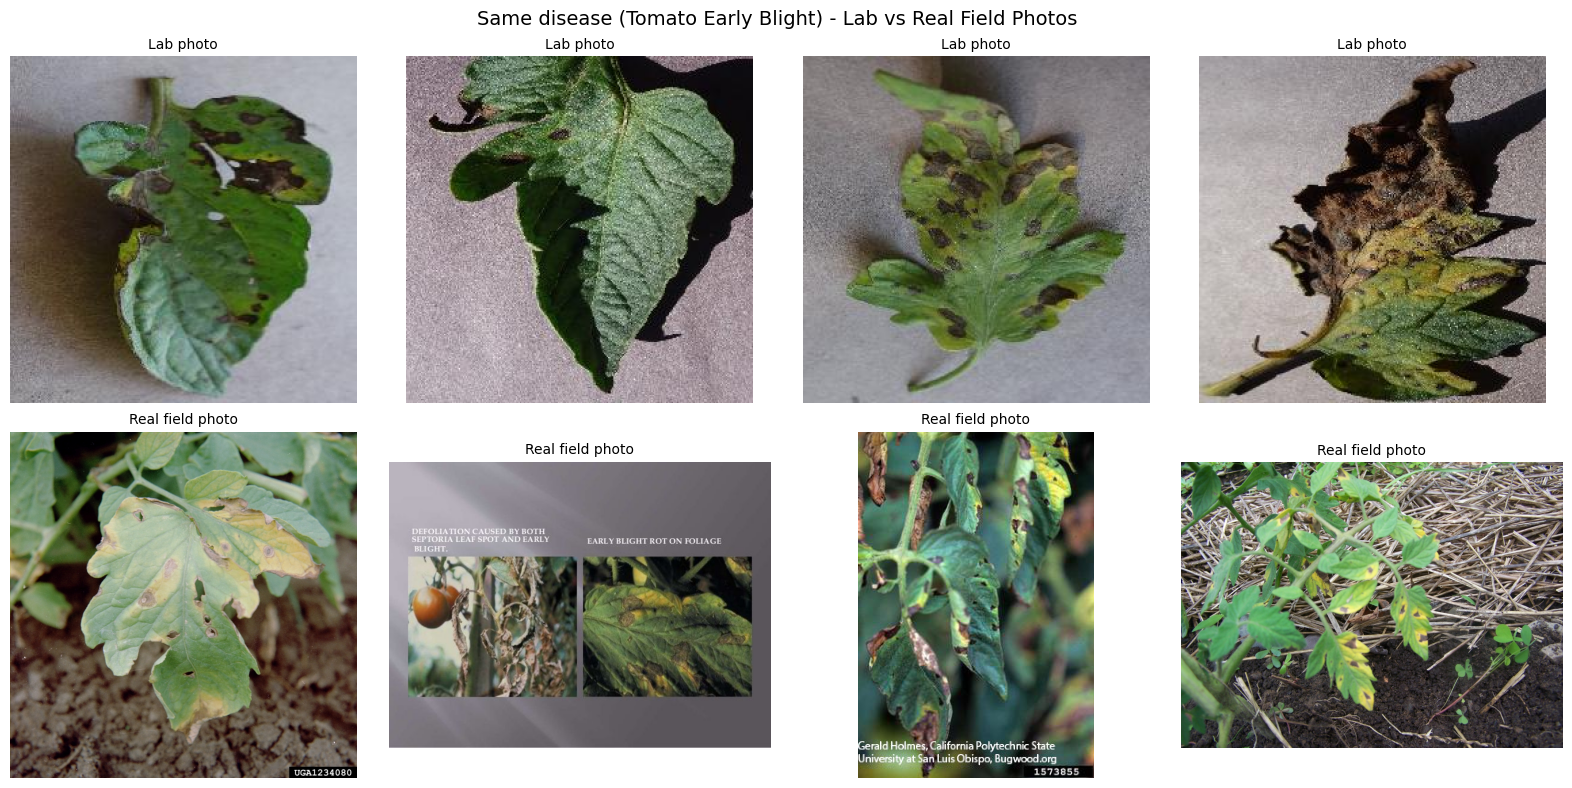

In [5]:
import matplotlib.pyplot as plt
from PIL import Image as PILImage

print("=== Training set class counts ===")
for split in ["train", "valid"]:
    for crop_dir in ["tomato", "grape"]:
        crop_path = f"{DATA_DIR}/{split}/{crop_dir}"
        if os.path.isdir(crop_path):
            for cls in sorted(os.listdir(crop_path)):
                print(f"  {split}/{crop_dir}/{cls}: {len(os.listdir(f'{crop_path}/{cls}'))}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
lab_dir = f"{DATA_DIR}/train/tomato/Tomato___Early_blight"
field_dir = f"{FIELD_EVAL_DIR}/tomato/Tomato___Early_blight"
lab_files = os.listdir(lab_dir)[:4]
field_files = os.listdir(field_dir)[:4] if os.path.isdir(field_dir) else []
for i, f in enumerate(lab_files):
    axes[0, i].imshow(PILImage.open(f"{lab_dir}/{f}")); axes[0, i].set_title("Lab photo", fontsize=10); axes[0, i].axis("off")
for i, f in enumerate(field_files):
    axes[1, i].imshow(PILImage.open(f"{field_dir}/{f}")); axes[1, i].set_title("Real field photo", fontsize=10); axes[1, i].axis("off")
plt.suptitle("Same disease (Tomato Early Blight) - Lab vs Real Field Photos", fontsize=14)
plt.tight_layout()
plt.show()


## 5. Training setup

In [6]:
import timm, torch, torch.nn as nn, json
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
WINNING_ARCH = "mobilenetv3_large_100"   # already determined via bake-off in an earlier run

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 6. Training function — stable, deterministic, resumable

Three stages: head (frozen backbone, PlantVillage) -> finetune (full network, PlantVillage) -> field_finetune (frozen backbone again, ALL real field photos, fixed epochs). No "best epoch" selection anywhere - every epoch checkpoints for disconnect-safety, and the final epoch is the final model. Re-running with the same inputs gives the same result.

In [7]:
class FixedClassFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root, classes, transform):
        self.samples, self.transform = [], transform
        if os.path.isdir(root):
            for cls in os.listdir(root):
                if cls not in classes:
                    continue
                cls_idx = classes.index(cls)
                cls_dir = os.path.join(root, cls)
                for fname in os.listdir(cls_dir):
                    self.samples.append((os.path.join(cls_dir, fname), cls_idx))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        return self.transform(PILImage.open(path).convert("RGB")), label


def train_crop_model(crop_dir, tag, arch_name=None, epochs_head=3, epochs_finetune=5, epochs_field_finetune=6):
    arch_name = arch_name or WINNING_ARCH
    total_epochs = epochs_head + epochs_finetune + epochs_field_finetune
    ckpt_path = f"{CKPT_DIR}/{tag}_latest.pt"
    log_path  = f"{CKPT_DIR}/{tag}_log.csv"

    train_ds = datasets.ImageFolder(f"{DATA_DIR}/train/{crop_dir}", train_tfm)
    val_ds   = datasets.ImageFolder(f"{DATA_DIR}/valid/{crop_dir}", eval_tfm)
    classes = train_ds.classes

    expected_prefix = "Tomato___" if crop_dir == "tomato" else "Grape___"
    assert all(c.startswith(expected_prefix) for c in classes), (
        f"[{tag}] SANITY CHECK FAILED: crop_dir={crop_dir!r} but classes are {classes}"
    )
    print(f"[{tag}] arch={arch_name}  {len(classes)} classes: {classes}")

    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_dl   = DataLoader(val_ds, batch_size=32, num_workers=2)

    field_ds = FixedClassFolderDataset(f"{FIELD_FINETUNE_DIR}/{crop_dir}", classes, train_tfm)
    field_dl = DataLoader(field_ds, batch_size=16, shuffle=True, num_workers=2) if len(field_ds) > 0 else None
    print(f"[{tag}] field-finetune images available: {len(field_ds)}")
    per_class = Counter(classes[l] for _, l in field_ds.samples)
    for c in classes:
        print(f"    {c}: {per_class.get(c, 0)}")

    model = timm.create_model(arch_name, pretrained=True, num_classes=len(classes)).to(device)

    start_epoch = 0
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        if ckpt.get("arch_name") == arch_name and ckpt.get("crop_dir") == crop_dir:
            model.load_state_dict(ckpt["model_state"])
            start_epoch = ckpt["epoch"] + 1
            print(f"[{tag}] Resuming from epoch {start_epoch}/{total_epochs}")
        else:
            print(f"[{tag}] Checkpoint doesn\'t match current config (arch/crop) - starting fresh.")

    if start_epoch >= total_epochs:
        print(f"[{tag}] Already fully trained ({total_epochs} epochs).")
        return model, classes

    if not os.path.exists(log_path):
        with open(log_path, "w") as f:
            f.write("epoch,stage,train_loss,train_acc,lab_val_acc\n")

    loss_fn = nn.CrossEntropyLoss()
    field_start = epochs_head + epochs_finetune

    for epoch in range(start_epoch, total_epochs):
        if epoch < epochs_head:
            stage = "head"
            for p in model.parameters(): p.requires_grad = False
            for p in model.get_classifier().parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
            epoch_dl = train_dl
        elif epoch < field_start:
            stage = "finetune"
            for p in model.parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.parameters(), lr=1e-5)
            epoch_dl = train_dl
        else:
            stage = "field_finetune"
            for p in model.parameters(): p.requires_grad = False
            for p in model.get_classifier().parameters(): p.requires_grad = True
            opt = torch.optim.Adam(model.get_classifier().parameters(), lr=1e-3)
            if field_dl is None:
                print(f"[{tag}] no field data - skipping epoch {epoch+1}, holding weights steady.")
                torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                            "crop_dir": crop_dir, "classes": classes}, ckpt_path)
                continue
            epoch_dl = field_dl

        model.train()
        total, correct, running_loss = 0, 0, 0.0
        for imgs, labels in epoch_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            out = model(imgs)
            loss = loss_fn(out, labels)
            loss.backward()
            opt.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        vtotal, vcorrect = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                vcorrect += (out.argmax(1) == labels).sum().item()
                vtotal += imgs.size(0)
        val_acc = vcorrect / vtotal

        print(f"[{tag}] epoch {epoch+1}/{total_epochs} ({stage})  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  lab_val_acc={val_acc:.4f}")
        with open(log_path, "a") as f:
            f.write(f"{epoch},{stage},{train_loss:.4f},{train_acc:.4f},{val_acc:.4f}\n")
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "arch_name": arch_name,
                    "crop_dir": crop_dir, "classes": classes}, ckpt_path)

    return model, classes


In [8]:
import os
for f in ["tomato_latest.pt", "grape_latest.pt", "tomato_log.csv", "grape_log.csv", "tomato_best.pt", "grape_best.pt"]:
    path = f"{CKPT_DIR}/{f}"
    if os.path.exists(path):
        os.remove(path)
        print("Deleted", path)

## 7. Train both crops

In [9]:
tomato_model, tomato_classes = train_crop_model("tomato", tag="tomato")


[tomato] arch=mobilenetv3_large_100  10 classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
[tomato] field-finetune images available: 677
    Tomato___Bacterial_spot: 101
    Tomato___Early_blight: 79
    Tomato___Late_blight: 101
    Tomato___Leaf_Mold: 85
    Tomato___Septoria_leaf_spot: 140
    Tomato___Spider_mites Two-spotted_spider_mite: 2
    Tomato___Target_Spot: 0
    Tomato___Tomato_Yellow_Leaf_Curl_Virus: 70
    Tomato___Tomato_mosaic_virus: 44
    Tomato___healthy: 55


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.1MB            

model.safetensors: downloading bytes:           |  0.00B            

[tomato] epoch 1/14 (head)  train_loss=1.1169  train_acc=0.6454  lab_val_acc=0.8414
[tomato] epoch 2/14 (head)  train_loss=0.4062  train_acc=0.8664  lab_val_acc=0.9016
[tomato] epoch 3/14 (head)  train_loss=0.2901  train_acc=0.9019  lab_val_acc=0.9276
[tomato] epoch 4/14 (finetune)  train_loss=0.1983  train_acc=0.9360  lab_val_acc=0.9535
[tomato] epoch 5/14 (finetune)  train_loss=0.1309  train_acc=0.9570  lab_val_acc=0.9644
[tomato] epoch 6/14 (finetune)  train_loss=0.0949  train_acc=0.9688  lab_val_acc=0.9725
[tomato] epoch 7/14 (finetune)  train_loss=0.0684  train_acc=0.9774  lab_val_acc=0.9810
[tomato] epoch 8/14 (finetune)  train_loss=0.0513  train_acc=0.9838  lab_val_acc=0.9812
[tomato] epoch 9/14 (field_finetune)  train_loss=3.7491  train_acc=0.2260  lab_val_acc=0.5882
[tomato] epoch 10/14 (field_finetune)  train_loss=3.0915  train_acc=0.2954  lab_val_acc=0.4977
[tomato] epoch 11/14 (field_finetune)  train_loss=2.6325  train_acc=0.3397  lab_val_acc=0.5278
[tomato] epoch 12/14 (fi

In [10]:
grape_model, grape_classes = train_crop_model("grape", tag="grape")


[grape] arch=mobilenetv3_large_100  4 classes: ['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']
[grape] field-finetune images available: 113
    Grape___Black_rot: 56
    Grape___Esca_(Black_Measles): 0
    Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 0
    Grape___healthy: 57
[grape] epoch 1/14 (head)  train_loss=1.1056  train_acc=0.6549  lab_val_acc=0.8648
[grape] epoch 2/14 (head)  train_loss=0.2815  train_acc=0.9000  lab_val_acc=0.9463
[grape] epoch 3/14 (head)  train_loss=0.1637  train_acc=0.9434  lab_val_acc=0.9612
[grape] epoch 4/14 (finetune)  train_loss=0.0896  train_acc=0.9675  lab_val_acc=0.9795
[grape] epoch 5/14 (finetune)  train_loss=0.0480  train_acc=0.9820  lab_val_acc=0.9906
[grape] epoch 6/14 (finetune)  train_loss=0.0334  train_acc=0.9875  lab_val_acc=0.9945
[grape] epoch 7/14 (finetune)  train_loss=0.0257  train_acc=0.9909  lab_val_acc=0.9967
[grape] epoch 8/14 (finetune)  train_loss=0.0127  train_

## 8. Evaluate on real field photos — the honest, final number

In [11]:
from sklearn.metrics import classification_report

def evaluate_on_field(model, classes, crop_dir):
    field_path = f"{FIELD_EVAL_DIR}/{crop_dir}"
    if not os.path.isdir(field_path):
        print(f"No field-eval images found for {crop_dir}")
        return
    field_ds = datasets.ImageFolder(field_path, eval_tfm)
    if len(field_ds) == 0:
        print(f"No field-eval images found for {crop_dir}")
        return
    field_dl = DataLoader(field_ds, batch_size=32)
    remap = [classes.index(c) if c in classes else -1 for c in field_ds.classes]

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in field_dl:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend([remap[l] for l in labels.numpy()])

    print(f"--- {crop_dir} field accuracy ---")
    print(classification_report(all_labels, all_preds, labels=list(range(len(classes))),
                                 target_names=classes, zero_division=0))

evaluate_on_field(tomato_model, tomato_classes, "tomato")
evaluate_on_field(grape_model, grape_classes, "grape")


--- tomato field accuracy ---
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.20      0.22      0.21         9
                        Tomato___Early_blight       0.60      0.33      0.43         9
                         Tomato___Late_blight       0.42      0.50      0.45        10
                           Tomato___Leaf_Mold       0.20      0.17      0.18         6
                  Tomato___Septoria_leaf_spot       0.38      0.55      0.44        11
Tomato___Spider_mites Two-spotted_spider_mite       0.00      0.00      0.00         0
                         Tomato___Target_Spot       0.00      0.00      0.00         0
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.56      0.83      0.67         6
                 Tomato___Tomato_mosaic_virus       0.43      0.30      0.35        10
                             Tomato___healthy       0.80      0.50      0.62         8

           

## 9. Export final models

In [12]:
torch.save(tomato_model.state_dict(), f"{PROJECT_DIR}/tomato_model_final.pt")
torch.save(grape_model.state_dict(), f"{PROJECT_DIR}/grape_model_final.pt")
json.dump({"classes": tomato_classes, "arch": WINNING_ARCH}, open(f"{PROJECT_DIR}/tomato_meta.json", "w"))
json.dump({"classes": grape_classes, "arch": WINNING_ARCH}, open(f"{PROJECT_DIR}/grape_meta.json", "w"))
print("Final models saved to", PROJECT_DIR)


Final models saved to /content/drive/MyDrive/crop-disease-model


## 10. predict() — for the demo notebook and eventual backend handoff

In [13]:
def predict(crop: str, image_path: str):
    model, classes = (tomato_model, tomato_classes) if crop == "tomato" else (grape_model, grape_classes)
    img = eval_tfm(PILImage.open(image_path).convert("RGB")).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(img), dim=1)[0]
    conf, idx = probs.max(0)
    label = classes[idx.item()].split("___")[-1]
    severity = "high" if conf > 0.85 else "medium" if conf > 0.6 else "low"
    return {"crop": crop, "disease": label, "confidence": round(conf.item(), 3), "severity": severity}
